In [69]:
import pandas as pd
df = pd.read_csv('./delhi.csv')
df.head()
df.tail()

,time,temperature_2m_max (°C),temperature_2m_min (°C),rain_sum (mm),precipitation_sum (mm),precipitation_hours (h),sunshine_duration (s),weather_code (wmo code),wind_direction_10m_dominant (°),relative_humidity_2m_mean (%),wind_speed_10m_max (km/h)
1236,2026-05-21,43.0,32.3,0.0,0.0,0.0,42576.47,1,268,20,17.5
1237,2026-05-22,42.4,31.9,0.0,0.0,0.0,41497.63,1,307,21,14.2
1238,2026-05-23,41.5,30.8,0.0,0.0,0.0,42426.98,1,299,21,19.0
1239,2026-05-24,42.5,30.5,0.0,0.0,0.0,42067.36,1,280,19,16.9
1240,2026-05-25,43.2,32.1,0.1,0.1,1.0,42536.95,51,287,19,15.6


In [70]:
df.columns

Index(['time', 'temperature_2m_max (°C)', 'temperature_2m_min (°C)',
       'rain_sum (mm)', 'precipitation_sum (mm)', 'precipitation_hours (h)',
       'sunshine_duration (s)', 'weather_code (wmo code)',
       'wind_direction_10m_dominant (°)', 'relative_humidity_2m_mean (%)',
       'wind_speed_10m_max (km/h)'],
      dtype='object')

In [71]:
df.isnull().sum()

time                               0
temperature_2m_max (°C)            0
temperature_2m_min (°C)            0
rain_sum (mm)                      0
precipitation_sum (mm)             0
precipitation_hours (h)            0
sunshine_duration (s)              0
weather_code (wmo code)            0
wind_direction_10m_dominant (°)    0
relative_humidity_2m_mean (%)      0
wind_speed_10m_max (km/h)          0
dtype: int64

In [72]:
df.shape

(1241, 11)

In [73]:
# targets for next day prediction

df["target_max_temp"] = df["temperature_2m_max (°C)"].shift(-1)

df["target_min_temp"] = df["temperature_2m_min (°C)"].shift(-1)

df["target_weather_code"] = df["weather_code (wmo code)"].shift(-1)

# remove last row (because target becomes NaN)
df = df.dropna()

print(df[[
    "temperature_2m_max (°C)",
    "target_max_temp",
    "temperature_2m_min (°C)",
    "target_min_temp",
    "weather_code (wmo code)",
    "target_weather_code"
]].head())

   temperature_2m_max (°C)  target_max_temp  temperature_2m_min (°C)  \
0                     18.1             17.8                      7.4   
1                     17.8             16.5                      6.4   
2                     16.5             16.5                      5.6   
3                     16.5             15.4                      4.9   
4                     15.4             13.9                      4.6   

   target_min_temp  weather_code (wmo code)  target_weather_code  
0              6.4                        3                  3.0  
1              5.6                        3                  3.0  
2              4.9                        3                  3.0  
3              4.6                        3                  3.0  
4              4.0                        3                  3.0  


In [74]:
df["time"] = pd.to_datetime(df["time"])
df["month"] = df["time"].dt.month
df["day"] = df["time"].dt.day
df["day_of_week"] = df["time"].dt.dayofweek
df["day_of_year"] = df["time"].dt.dayofyear


features = [

    "temperature_2m_max (°C)",
    "temperature_2m_min (°C)",
    "rain_sum (mm)",
    "month",
    "day",
    "day_of_week",
    "day_of_year",
    "precipitation_sum (mm)",
    "precipitation_hours (h)",
    "sunshine_duration (s)",
    "relative_humidity_2m_mean (%)",
    "wind_speed_10m_max (km/h)",
    "wind_direction_10m_dominant (°)",
    "weather_code (wmo code)"

]

X = df[features]

y_max = df["target_max_temp"]

y_min = df["target_min_temp"]

y_weather = df["target_weather_code"]

print(X.head())

print(y_max.head())

   temperature_2m_max (°C)  temperature_2m_min (°C)  rain_sum (mm)  month  \
0                     18.1                      7.4            0.0      1   
1                     17.8                      6.4            0.0      1   
2                     16.5                      5.6            0.0      1   
3                     16.5                      4.9            0.0      1   
4                     15.4                      4.6            0.0      1   

   day  day_of_week  day_of_year  precipitation_sum (mm)  \
0    1            6            1                     0.0   
1    2            0            2                     0.0   
2    3            1            3                     0.0   
3    4            2            4                     0.0   
4    5            3            5                     0.0   

   precipitation_hours (h)  sunshine_duration (s)  \
0                      0.0               35237.45   
1                      0.0               36000.00   
2                

In [75]:
split_index = int(len(df) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_max_train = y_max.iloc[:split_index]
y_max_test = y_max.iloc[split_index:]

y_min_train = y_min.iloc[:split_index]
y_min_test = y_min.iloc[split_index:]

y_weather_train = y_weather.iloc[:split_index]
y_weather_test = y_weather.iloc[split_index:]

print(X_train.shape)
print(X_test.shape)

(992, 14)
(248, 14)


In [76]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

# create model
max_model = RandomForestRegressor(
    n_estimators=300,
    random_state=42
)

# train
max_model.fit(X_train, y_max_train)

# predict
max_predictions = max_model.predict(X_test)

# evaluate
mae = mean_absolute_error(y_max_test, max_predictions)

print("MAE:", mae)
# accuracy score
print("Accuracy:", max_model.score(X_test, y_max_test))

print("\nFirst 10 Predictions:\n")

for real, pred in zip(y_max_test[:10], max_predictions[:10]):
    print(f"Actual: {real:.1f} | Predicted: {pred:.1f}")

MAE: 1.2215147849462362
Accuracy: 0.9379845456764896

First 10 Predictions:

Actual: 36.2 | Predicted: 35.7
Actual: 36.5 | Predicted: 36.4
Actual: 37.1 | Predicted: 36.5
Actual: 36.8 | Predicted: 37.0
Actual: 36.2 | Predicted: 36.9
Actual: 36.3 | Predicted: 36.5
Actual: 37.0 | Predicted: 36.4
Actual: 38.5 | Predicted: 36.8
Actual: 37.0 | Predicted: 37.1
Actual: 36.8 | Predicted: 35.7


In [77]:
# MIN TEMP MODEL

min_model = RandomForestRegressor(
    n_estimators=300,
    random_state=42
)

# train
min_model.fit(X_train, y_min_train)

# predict
min_predictions = min_model.predict(X_test)

# evaluate
min_mae = mean_absolute_error(y_min_test, min_predictions)

print("MIN TEMP MAE:", min_mae)

# accuracy score
print("MIN TEMP Accuracy:", min_model.score(X_test, y_min_test))

print("\nFirst 10 Predictions:\n")

for real, pred in zip(y_min_test[:10], min_predictions[:10]):
    print(f"Actual: {real:.1f} | Predicted: {pred:.1f}")
# accuracy


MIN TEMP MAE: 0.9432473118279576
MIN TEMP Accuracy: 0.9664777869025619

First 10 Predictions:

Actual: 26.3 | Predicted: 27.1
Actual: 26.0 | Predicted: 27.1
Actual: 26.6 | Predicted: 26.1
Actual: 26.6 | Predicted: 26.7
Actual: 26.2 | Predicted: 26.7
Actual: 26.2 | Predicted: 26.9
Actual: 25.8 | Predicted: 27.0
Actual: 26.9 | Predicted: 26.0
Actual: 28.6 | Predicted: 27.0
Actual: 24.9 | Predicted: 28.0


In [78]:
def simplify_weather(code):

    if code == 0:
        return "sunny"

    elif code in [1, 2, 3]:
        return "cloudy"

    elif code in [45, 48]:
        return "foggy"

    elif code in [51, 53, 55, 61, 63, 65]:
        return "rainy"

    elif code in [71, 73, 75]:
        return "snowy"

    elif code >= 95:
        return "stormy"

    else:
        return "other"


df["weather_label"] = df["weather_code (wmo code)"].apply(simplify_weather)

df["target_weather_label"] = df["target_weather_code"].apply(simplify_weather)

print(df[[
    "weather_code (wmo code)",
    "weather_label",
    "target_weather_code",
    "target_weather_label"
]].head(10))

   weather_code (wmo code) weather_label  target_weather_code  \
0                        3        cloudy                  3.0   
1                        3        cloudy                  3.0   
2                        3        cloudy                  3.0   
3                        3        cloudy                  3.0   
4                        3        cloudy                  3.0   
5                        3        cloudy                  3.0   
6                        3        cloudy                  3.0   
7                        3        cloudy                  3.0   
8                        3        cloudy                  3.0   
9                        3        cloudy                  3.0   

  target_weather_label  
0               cloudy  
1               cloudy  
2               cloudy  
3               cloudy  
4               cloudy  
5               cloudy  
6               cloudy  
7               cloudy  
8               cloudy  
9               cloudy  


In [79]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# split weather labels

y_weather_label = df["target_weather_label"]

y_weather_train = y_weather_label.iloc[:split_index]
y_weather_test = y_weather_label.iloc[split_index:]

# create classifier

weather_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42
)

# train

weather_model.fit(X_train, y_weather_train)

# predict

weather_predictions = weather_model.predict(X_test)

# accuracy

accuracy = accuracy_score(
    y_weather_test,
    weather_predictions
)

print("Accuracy:", accuracy)

print("\nFirst 20 Predictions:\n")

for real, pred in zip(
    y_weather_test[:20],
    weather_predictions[:20]
):
    print(f"Actual: {real} | Predicted: {pred}")

Accuracy: 0.625

First 20 Predictions:

Actual: cloudy | Predicted: rainy
Actual: cloudy | Predicted: cloudy
Actual: sunny | Predicted: cloudy
Actual: cloudy | Predicted: cloudy
Actual: sunny | Predicted: cloudy
Actual: sunny | Predicted: cloudy
Actual: sunny | Predicted: cloudy
Actual: rainy | Predicted: cloudy
Actual: sunny | Predicted: rainy
Actual: rainy | Predicted: cloudy
Actual: rainy | Predicted: rainy
Actual: rainy | Predicted: rainy
Actual: rainy | Predicted: rainy
Actual: rainy | Predicted: rainy
Actual: cloudy | Predicted: rainy
Actual: rainy | Predicted: sunny
Actual: rainy | Predicted: rainy
Actual: rainy | Predicted: rainy
Actual: rainy | Predicted: rainy
Actual: rainy | Predicted: sunny


In [80]:
latest_data = X.iloc[-1]

print(latest_data)

temperature_2m_max (°C)               42.50
temperature_2m_min (°C)               30.50
rain_sum (mm)                          0.00
month                                  5.00
day                                   24.00
day_of_week                            6.00
day_of_year                          144.00
precipitation_sum (mm)                 0.00
precipitation_hours (h)                0.00
sunshine_duration (s)              42067.36
relative_humidity_2m_mean (%)         19.00
wind_speed_10m_max (km/h)             16.90
wind_direction_10m_dominant (°)      280.00
weather_code (wmo code)                1.00
Name: 1239, dtype: float64


In [81]:
future_predictions = []

current_input = latest_data.copy()

for day in range(7):

    # predict temperatures
    next_max = max_model.predict([current_input])[0]
    next_min = min_model.predict([current_input])[0]

    # predict weather
    next_weather = weather_model.predict([current_input])[0]
    weather_mapping = {
    "sunny": 0,
    "cloudy": 3,
    "rainy": 61,
    "foggy": 45,
    "snowy": 71,
    "stormy": 95,
    "other": 1
    }

    current_input["weather_code (wmo code)"] = (
        weather_mapping[next_weather]
    )

    # store prediction
    future_predictions.append({
        "day": day + 1,
        "predicted_max_temp": float(round(next_max, 1)),
        "predicted_min_temp": float(round(next_min, 1)),
        "predicted_weather": next_weather
    })

    # update inputs for next prediction
    current_input["temperature_2m_max (°C)"] = next_max
    current_input["temperature_2m_min (°C)"] = next_min

print("\n7-Day Forecast:\n")

for forecast in future_predictions:
    print(forecast)


7-Day Forecast:

{'day': 1, 'predicted_max_temp': 43.4, 'predicted_min_temp': 29.7, 'predicted_weather': 'cloudy'}
{'day': 2, 'predicted_max_temp': 43.1, 'predicted_min_temp': 29.9, 'predicted_weather': 'cloudy'}
{'day': 3, 'predicted_max_temp': 43.2, 'predicted_min_temp': 29.7, 'predicted_weather': 'cloudy'}
{'day': 4, 'predicted_max_temp': 43.1, 'predicted_min_temp': 29.8, 'predicted_weather': 'cloudy'}
{'day': 5, 'predicted_max_temp': 43.2, 'predicted_min_temp': 29.7, 'predicted_weather': 'cloudy'}
{'day': 6, 'predicted_max_temp': 43.1, 'predicted_min_temp': 29.7, 'predicted_weather': 'cloudy'}
{'day': 7, 'predicted_max_temp': 43.2, 'predicted_min_temp': 29.7, 'predicted_weather': 'cloudy'}


/opt/anaconda3/envs/dsenv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/dsenv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/dsenv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/dsenv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/dsenv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but RandomFo

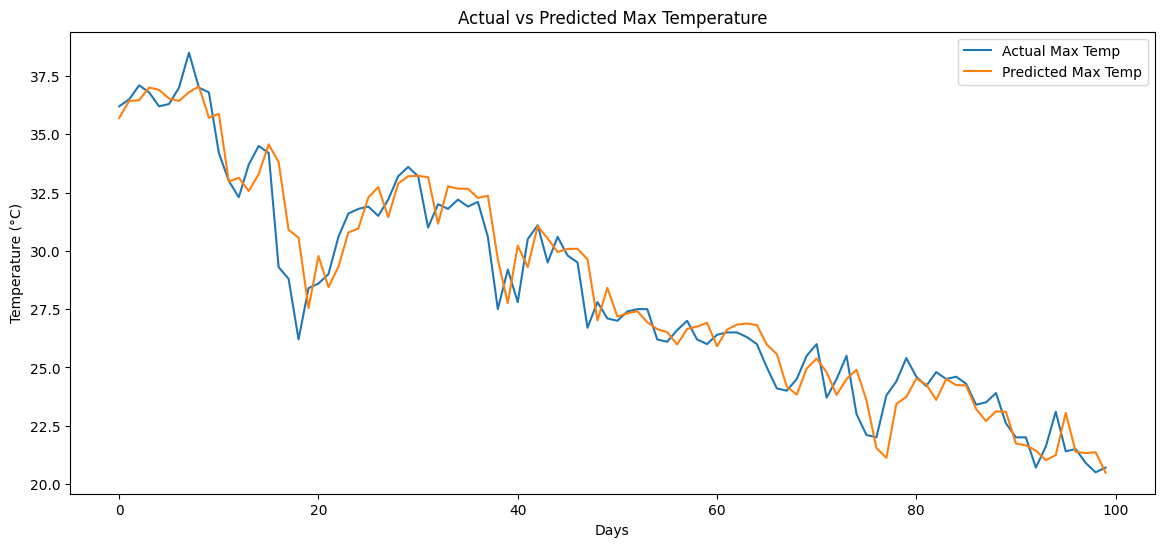

In [82]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))

plt.plot(
    y_max_test.values[:100],
    label="Actual Max Temp"
)

plt.plot(
    max_predictions[:100],
    label="Predicted Max Temp"
)

plt.title("Actual vs Predicted Max Temperature")

plt.xlabel("Days")
plt.ylabel("Temperature (°C)")

plt.legend()

plt.show()

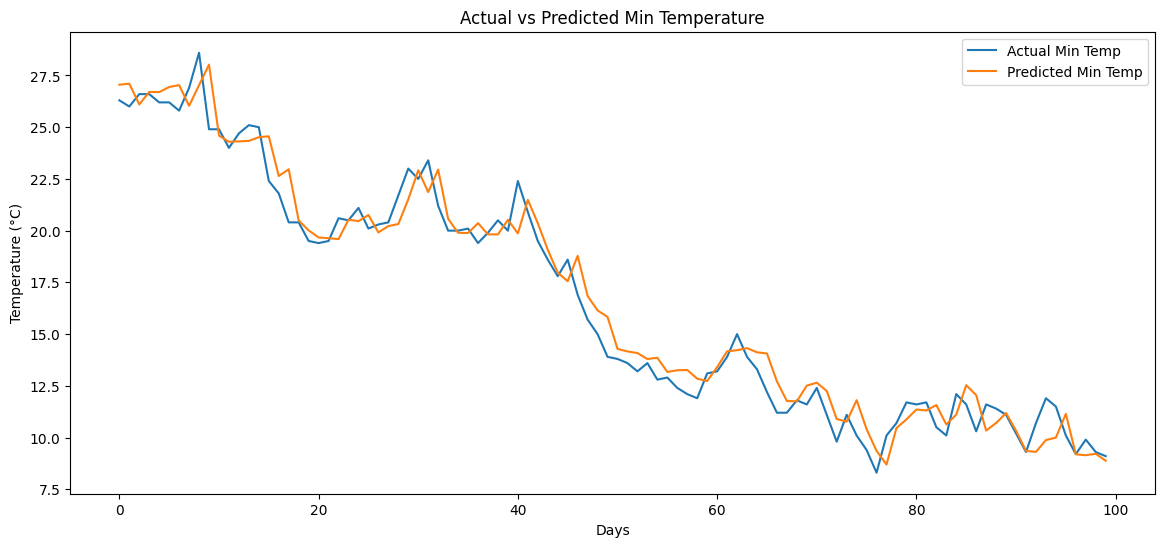

In [83]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))

plt.plot(
    y_min_test.values[:100],
    label="Actual Min Temp"
)

plt.plot(
    min_predictions[:100],
    label="Predicted Min Temp"
)

plt.title("Actual vs Predicted Min Temperature")

plt.xlabel("Days")
plt.ylabel("Temperature (°C)")

plt.legend()

plt.show()

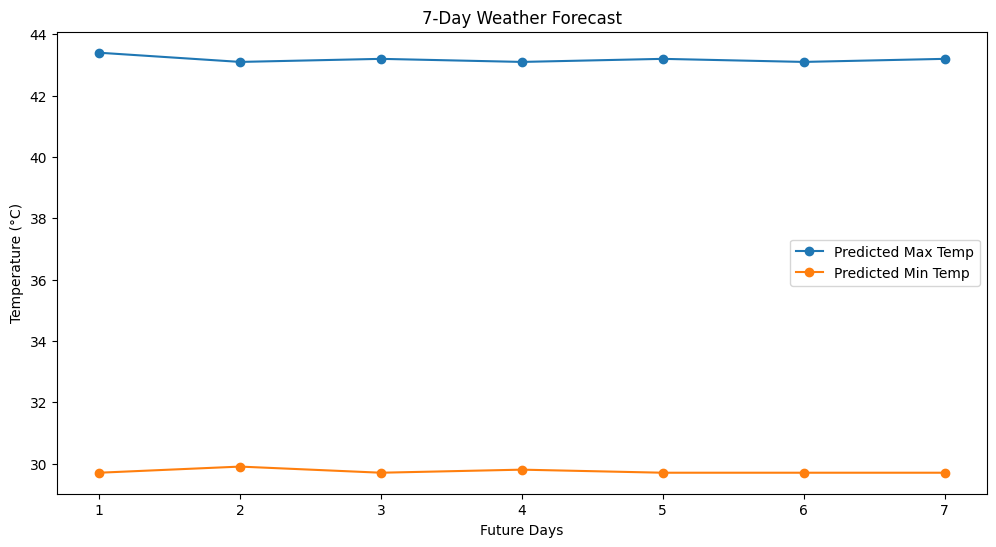

In [84]:
future_days = [x["day"] for x in future_predictions]

future_max = [
    x["predicted_max_temp"]
    for x in future_predictions
]

future_min = [
    x["predicted_min_temp"]
    for x in future_predictions
]

plt.figure(figsize=(12,6))

plt.plot(
    future_days,
    future_max,
    marker="o",
    label="Predicted Max Temp"
)

plt.plot(
    future_days,
    future_min,
    marker="o",
    label="Predicted Min Temp"
)

plt.title("7-Day Weather Forecast")

plt.xlabel("Future Days")
plt.ylabel("Temperature (°C)")

plt.xticks(future_days)

plt.legend()

plt.show()

In [85]:
import joblib

joblib.dump(max_model, "models/delhi/max.pkl")
joblib.dump(min_model, "models/delhi/min.pkl")
joblib.dump(weather_model, "models/delhi/weather.pkl")

['models/delhi/weather.pkl']

In [86]:
df.columns

Index(['time', 'temperature_2m_max (°C)', 'temperature_2m_min (°C)',
       'rain_sum (mm)', 'precipitation_sum (mm)', 'precipitation_hours (h)',
       'sunshine_duration (s)', 'weather_code (wmo code)',
       'wind_direction_10m_dominant (°)', 'relative_humidity_2m_mean (%)',
       'wind_speed_10m_max (km/h)', 'target_max_temp', 'target_min_temp',
       'target_weather_code', 'month', 'day', 'day_of_week', 'day_of_year',
       'weather_label', 'target_weather_label'],
      dtype='object')

In [90]:
df['target_weather_label'].value_counts()

target_weather_label
cloudy    553
rainy     420
sunny     267
Name: count, dtype: int64

In [93]:
df[df['month'] == 4]

,time,temperature_2m_max (°C),temperature_2m_min (°C),rain_sum (mm),precipitation_sum (mm),precipitation_hours (h),sunshine_duration (s),weather_code (wmo code),wind_direction_10m_dominant (°),relative_humidity_2m_mean (%),wind_speed_10m_max (km/h),target_max_temp,target_min_temp,target_weather_code,month,day,day_of_week,day_of_year,weather_label,target_weather_label
90,2023-04-01,25.3,16.1,1.2,1.2,5.0,40904.46,53,51,80,11.6,28.4,16.1,2.0,4,1,5,91,rainy,cloudy
91,2023-04-02,28.4,16.1,0.0,0.0,0.0,41772.14,2,300,71,17.3,31.2,17.2,2.0,4,2,6,92,cloudy,cloudy
92,2023-04-03,31.2,17.2,0.0,0.0,0.0,42366.06,2,10,63,17.5,28.2,15.9,3.0,4,3,0,93,cloudy,cloudy
93,2023-04-04,28.2,15.9,0.0,0.0,0.0,36978.34,3,325,64,16.9,30.3,16.1,0.0,4,4,1,94,cloudy,sunny
94,2023-04-05,30.3,16.1,0.0,0.0,0.0,43200.00,0,316,49,16.2,31.8,17.0,2.0,4,5,2,95,sunny,cloudy
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1211,2026-04-26,41.7,28.4,0.0,0.0,0.0,37071.82,3,299,25,20.6,42.3,29.0,3.0,4,26,6,116,cloudy,cloudy
1212,2026-04-27,42.3,29.0,0.0,0.0,0.0,41517.48,3,288,23,19.6,37.2,27.4,51.0,4,27,0,117,cloudy,rainy
1213,2026-04-28,37.2,27.4,0.3,0.3,1.0,36431.51,51,7,35,10.1,37.3,27.1,3.0,4,28,1,118,rainy,cloudy
1214,2026-04-29,37.3,27.1,0.0,0.0,0.0,34401.25,3,87,38,8.9,37.7,23.1,2.0,4,29,2,119,cloudy,cloudy
